# 01 — Data Understanding

The purpose of this notebook is to understand the dataset before doing any preprocessing or modeling.

In this notebook, we will:
- Load the dataset
- Inspect its shape and columns
- Review data types
- Check missing values and duplicates
- Summarize numerical variables
- Inspect the target variable (`Exited`)
- Write down first observations

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [13]:
# Read the dataset and display the first few rows
df = pd.read_csv('../data/raw/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


By displaying the head of the dataset, we can see all the columns and some example values they contain. This gives us an initial understanding of the data and helps us start identifying which features may be useful for predicting customer churn.

## 1. Dataset shape

In [ ]:
# Check the shape of the dataset
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 10000
Columns: 14


The dataset contains 10,000 records and 14 columns. Given this size, the project can be carried out efficiently on a local machine without the need for distributed tools such as Spark or cloud-based systems. This is because the dataset is relatively small, easy to load into memory, and fast to process with libraries like pandas and scikit-learn. For this project, working locally is more practical, simpler to set up, and fully sufficient for exploration, preprocessing, and model training.

## 2. Column names and data types

In [ ]:
# Display data types and non-null counts for each column
# We could also do this with df.info(), but here we create a custom DataFrame for better readability

pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null_count': df.notnull().sum().values,
})

,column,dtype,non_null_count
0,RowNumber,int64,10000
1,CustomerId,int64,10000
2,Surname,object,10000
3,CreditScore,int64,10000
4,Geography,object,10000
5,Gender,object,10000
6,Age,int64,10000
7,Tenure,int64,10000
8,Balance,float64,10000
9,NumOfProducts,int64,10000


We can now inspect the data type of each column and the number of non-null values in each of them. In this dataset, every column has the maximum number of non-null values, which indicates that there are no missing values.

## 3. Missing values

In [ ]:
# Check for missing values in the dataset
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

From the previous step, we already know that the dataset contains no missing values, which is helpful for the next stages of the analysis. This code confirms that result by counting the missing values in each column, sorting them from highest to lowest, and displaying only the columns where missing values are present.

## 4. Duplicate rows

In [16]:
# Check for duplicate rows in the dataset
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

Duplicate rows: 0


There are no duplicate records in the dataset, which is another positive sign for the quality of the data.

## 5. Numerical summary

In [ ]:
# Display summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.00,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
CustomerId,10000.00,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
CreditScore,10000.00,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.00,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.00,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.00,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.00,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.00,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.00,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.00,100090.24,57510.49,11.58,51002.11,100193.91,149388.25,199992.48


In this section, we can analyze the main statistical values for each numerical feature, such as the mean, standard deviation, minimum, maximum, and percentiles. This perspective is important because it helps us better understand the distribution of the data and assess whether the features are suitable for training a machine learning model.

## 6. Categorical summary

In [ ]:
# Display value counts for categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts().head(10))


--- Surname ---
Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
Genovese    25
Yeh         25
Shih        25
Wright      24
Maclean     24
Name: count, dtype: int64

--- Geography ---
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

--- Gender ---
Gender
Male      5457
Female    4543
Name: count, dtype: int64


At this stage, we can ask whether it is appropriate to convert the categorical columns into numerical variables or whether some of them should be dropped. This is an important question because machine learning models usually require numerical inputs, but not every categorical feature is necessarily useful for prediction.

In this case, we may assume that the `Surname` column does not have a meaningful influence on whether a customer leaves the bank, so it is likely to be removed rather than encoded.

## 7. Target variable (`Exited`)

In [ ]:
# Display the distribution of the target variable 'Exited'
target_counts = df['Exited'].value_counts().sort_index()
target_percent = df['Exited'].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    'count': target_counts,
    'percentage': target_percent.round(2)
}))

,count,percentage
Exited,,
0,7963,79.63
1,2037,20.37


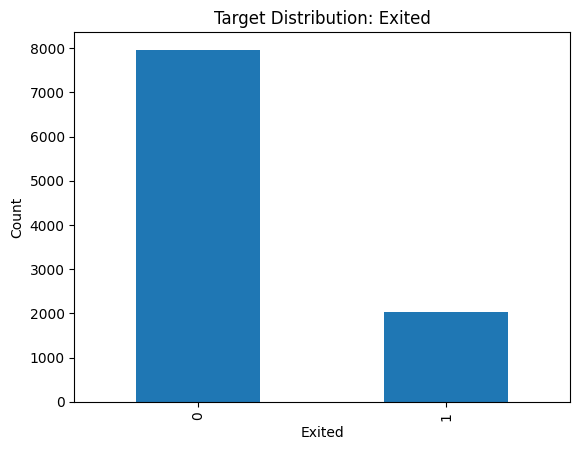

In [11]:
df['Exited'].value_counts().plot(kind='bar')
plt.title('Target Distribution: Exited')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

Looking at the distribution of the `Exited` variable, it appears that the target is imbalanced. Therefore, when evaluating the model, we should consider metrics beyond accuracy.

## 8. First observations and conclusions

- `Exited` is the target variable for the churn prediction problem.
- `RowNumber`, `CustomerId`, and `Surname` are likely not useful for predictive modeling.
- `Geography` and `Gender` are categorical features that will need encoding later.
- The most promising features for explaining churn in this dataset look like `Age`, `IsActiveMember`, `Geography`, `NumOfProducts` and `Balance`.
- The target variable `Exited` is imbalanced. Around 79.6% of customers did not churn, while only 20.4% churned. This indicates a moderate class imbalance, meaning accuracy alone may not be a reliable evaluation metric for the churn prediction model.